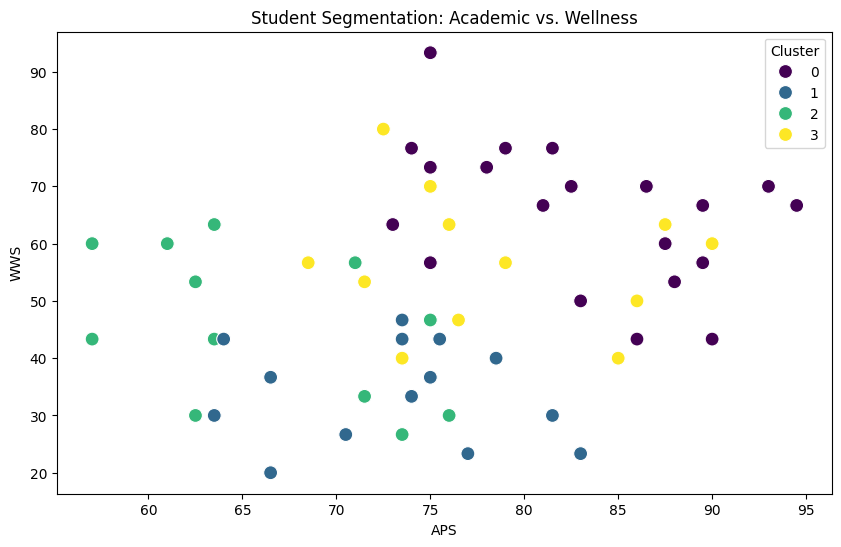

               APS        WWS       PTMS        CRS
Cluster                                            
0        83.075000  65.333333  53.250000  42.250000
1        73.400000  34.444444  62.366667  66.666667
2        66.166667  45.555556  46.958333  41.666667
3        78.423077  55.384615  82.192308  40.000000


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load data from Activity 2
df = pd.read_csv('/content/student_scores (1).csv') # Corrected path
features = ['APS', 'WWS', 'PTMS', 'CRS']
X = df[features]

# 2. Preprocessing: Normalization is vital for K-Means distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Visualization (Comparing APS vs. WWS)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='APS', y='WWS', hue='Cluster', palette='viridis', s=100)
plt.title('Student Segmentation: Academic vs. Wellness')
plt.show()

# 5. Analysis: Look at the means of each cluster to identify them
cluster_analysis = df.groupby('Cluster')[features].mean()
print(cluster_analysis)

In [7]:
# Compare Rule-Based (Category) with ML-Based (Cluster)
comparison = pd.crosstab(df['Category'], df['Cluster'])
print("Comparison Matrix (Rule-Based vs. ML Clusters):")
print(comparison)



Comparison Matrix (Rule-Based vs. ML Clusters):
Cluster                    0   1  2   3
Category                               
Green (Stable)             3   0  0   3
Red (At Risk)              2   1  7   0
Yellow (Needs Attention)  15  14  5  10
